In [1]:
import numpy as np
from samplers.SEIR_emcee import SEIR_emcee
from samplers.SEIR_pytwalk import SEIR_pytwalk
from samplers.SEIR_pyhmc import SEIR_pyhmc
from epidemic_model import SEIR_Model
from utils.utils import load_data, parser
import sys
import matplotlib.pyplot as plt
from time import time
from joblib import dump, load

In [2]:
from bokeh.io import output_notebook, show

output_notebook()

Loading BokehJS ...

Data loaded from file:  data/Smoothed_Cases_Third_Wave.csv


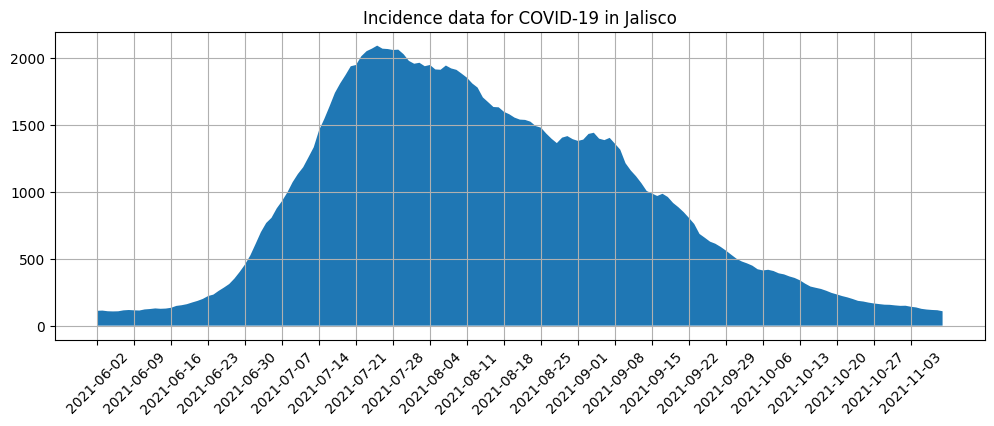

In [3]:
# Loading configuration from configuration file
fname_conf = './configuration_file_test.cfg'

params = parser(fname_conf)

times, data, dates = load_data(params['fname'])

print('Data loaded from file: ', params['fname'])

# plotting data
plt.figure(figsize=(12,4))
plt.fill_between(dates,data, label='Incidence data')
plt.xticks(dates[::7],rotation=45)
plt.title('Incidence data for COVID-19 in Jalisco')
plt.grid()
plt.show()


In [4]:
print(dates[0], dates[-1])
print(np.sum(data))

2021-06-02 2021-11-09
144769.7142857143


In [5]:
# Total population size is taken from the configuration file
N = params["N"]

# Setting initial conditions
E0 = data[0] 
I0 = params['I0']
R0 = 0
S0 = N - E0 - I0 - R0

x0 = [S0,E0,I0,R0]

iterations = params['iterations']  # Number of iterations for the MCMC sampler
ndim = 3                           # Dimension of the problem is 3: beta, sigma, gamma

reload_flag = (params['reload'] == 1)
out_file = params['outfile']
outpath = params['outpath']


In [6]:

#### Run this cell in case that are loading a previous run
if reload_flag :
    seir_twalk = load(outpath+'/pytwalk/'+out_file)
    seir_twalk.outpath = outpath

In [7]:
if not reload_flag :
        seir_twalk = SEIR_pytwalk(
                ndim=ndim,
                data=data,
                time=times,
                x0=x0,
                labels=['beta', 'sigma', 'gamma'],
                **params
                )

        xp0 = np.array([0.36,0.98,0.2])
        xp1 = np.array([0.5,1.00,0.15])


In [8]:
if not reload_flag :
    ini_time = time()
    seir_twalk.run(iterations,xp0,xp1)
    end_time = time()
    print('Time elapsed: ', end_time-ini_time)

    dump(seir_twalk, outpath+'/pytwalk/'+out_file)

In [9]:
seir_twalk.create_dictionary()

In [10]:
seir_twalk.summary()


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.275  0.054   0.186    0.325      0.033    0.006       3.0      42.0   
sigma  0.096  0.190   0.047    0.146      0.037    0.073       4.0      15.0   
gamma  0.033  0.022   0.000    0.054      0.004    0.007      16.0      29.0   

       r_hat  
beta    1.66  
sigma   1.99  
gamma   1.68  


        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.275  0.054   0.186    0.325      0.033    0.006       3.0      42.0   
sigma  0.096  0.190   0.047    0.146      0.037    0.073       4.0      15.0   
gamma  0.033  0.022   0.000    0.054      0.004    0.007      16.0      29.0   

       r_hat  
beta    1.66  
sigma   1.99  
gamma   1.68  


<Figure size 640x480 with 0 Axes>

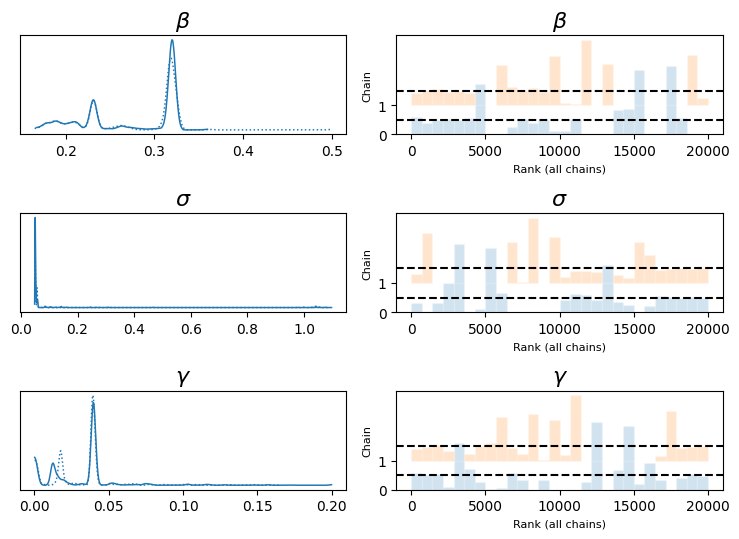

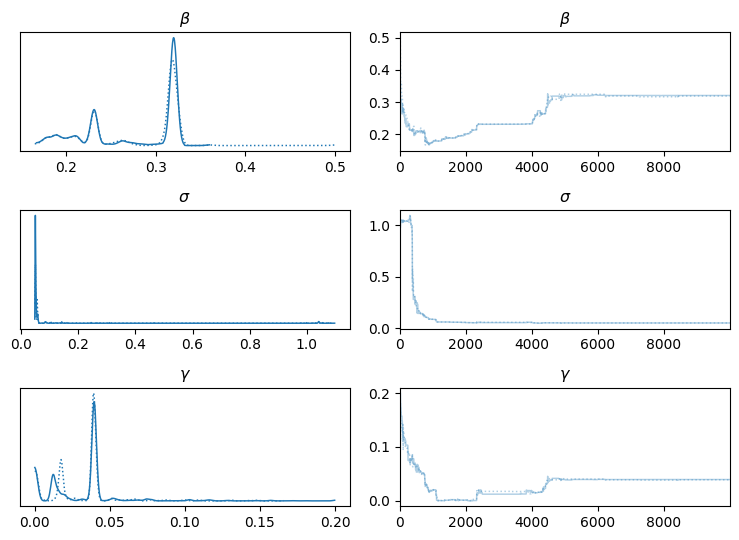

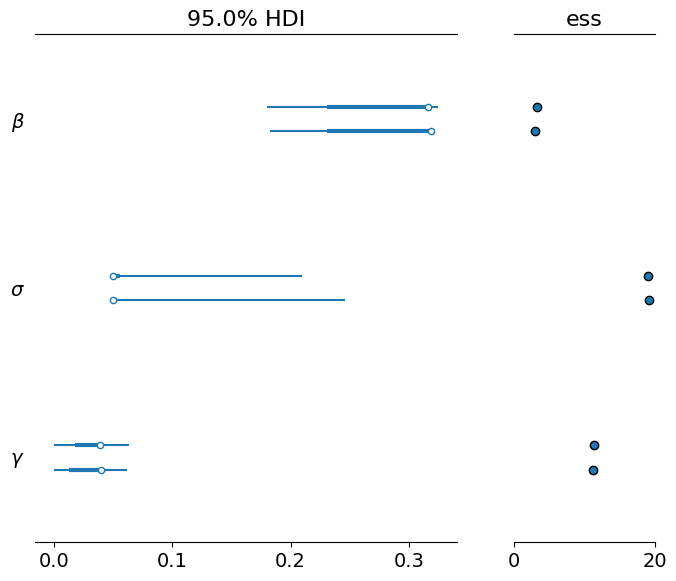

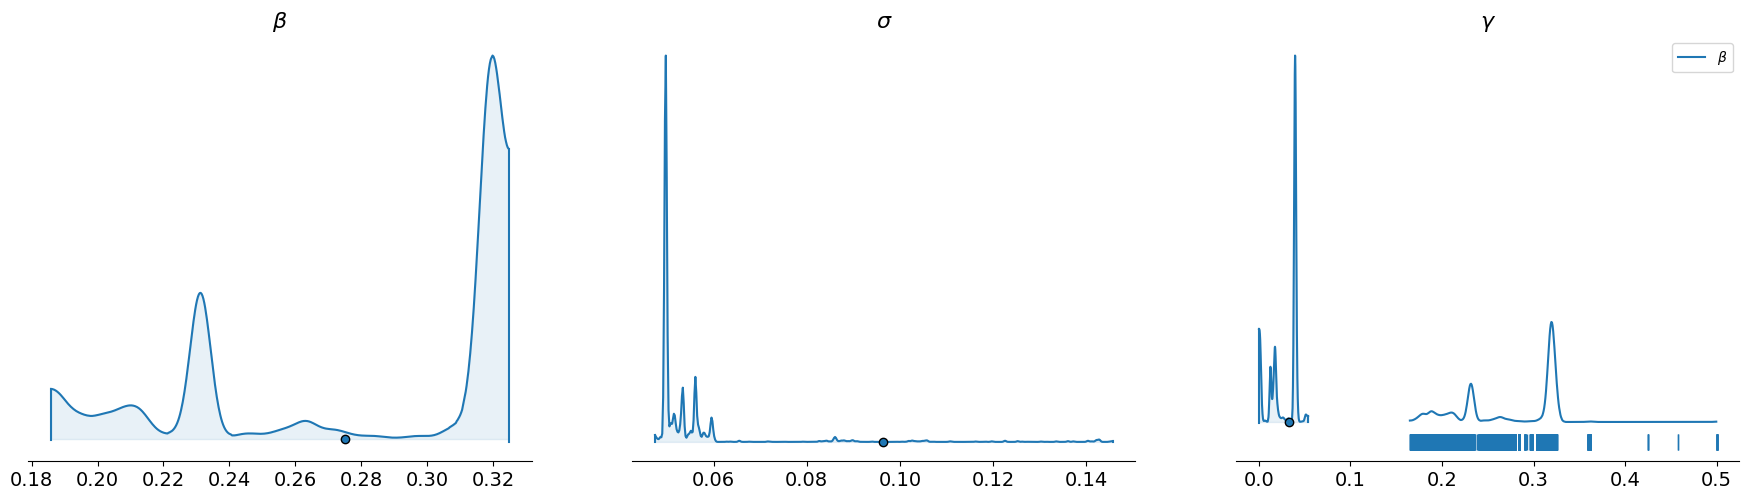

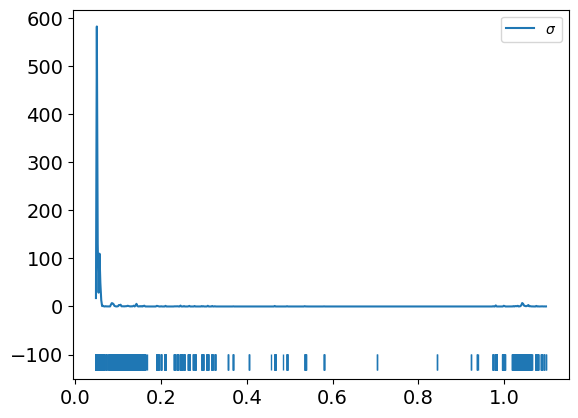

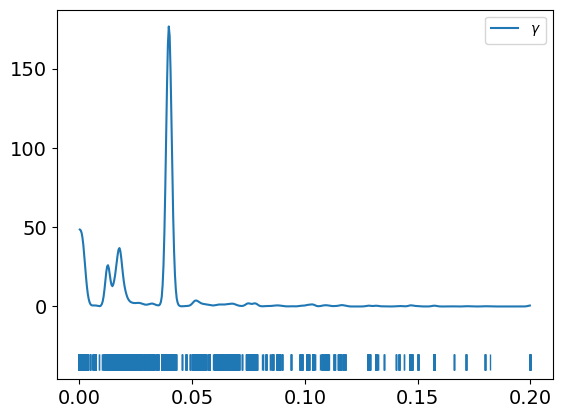

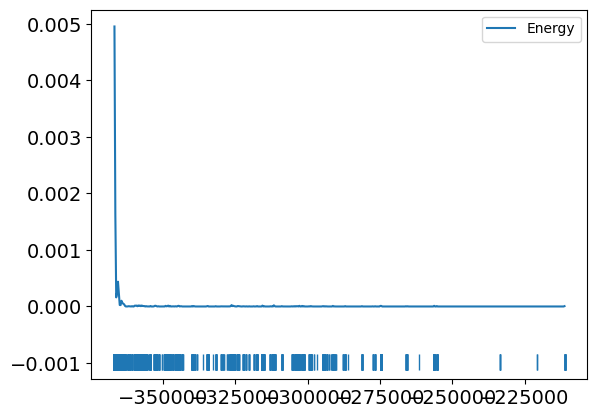

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 4999 samples


  2%|▏         | 196/9998 [00:03<02:43, 59.85it/s]


KeyboardInterrupt: 

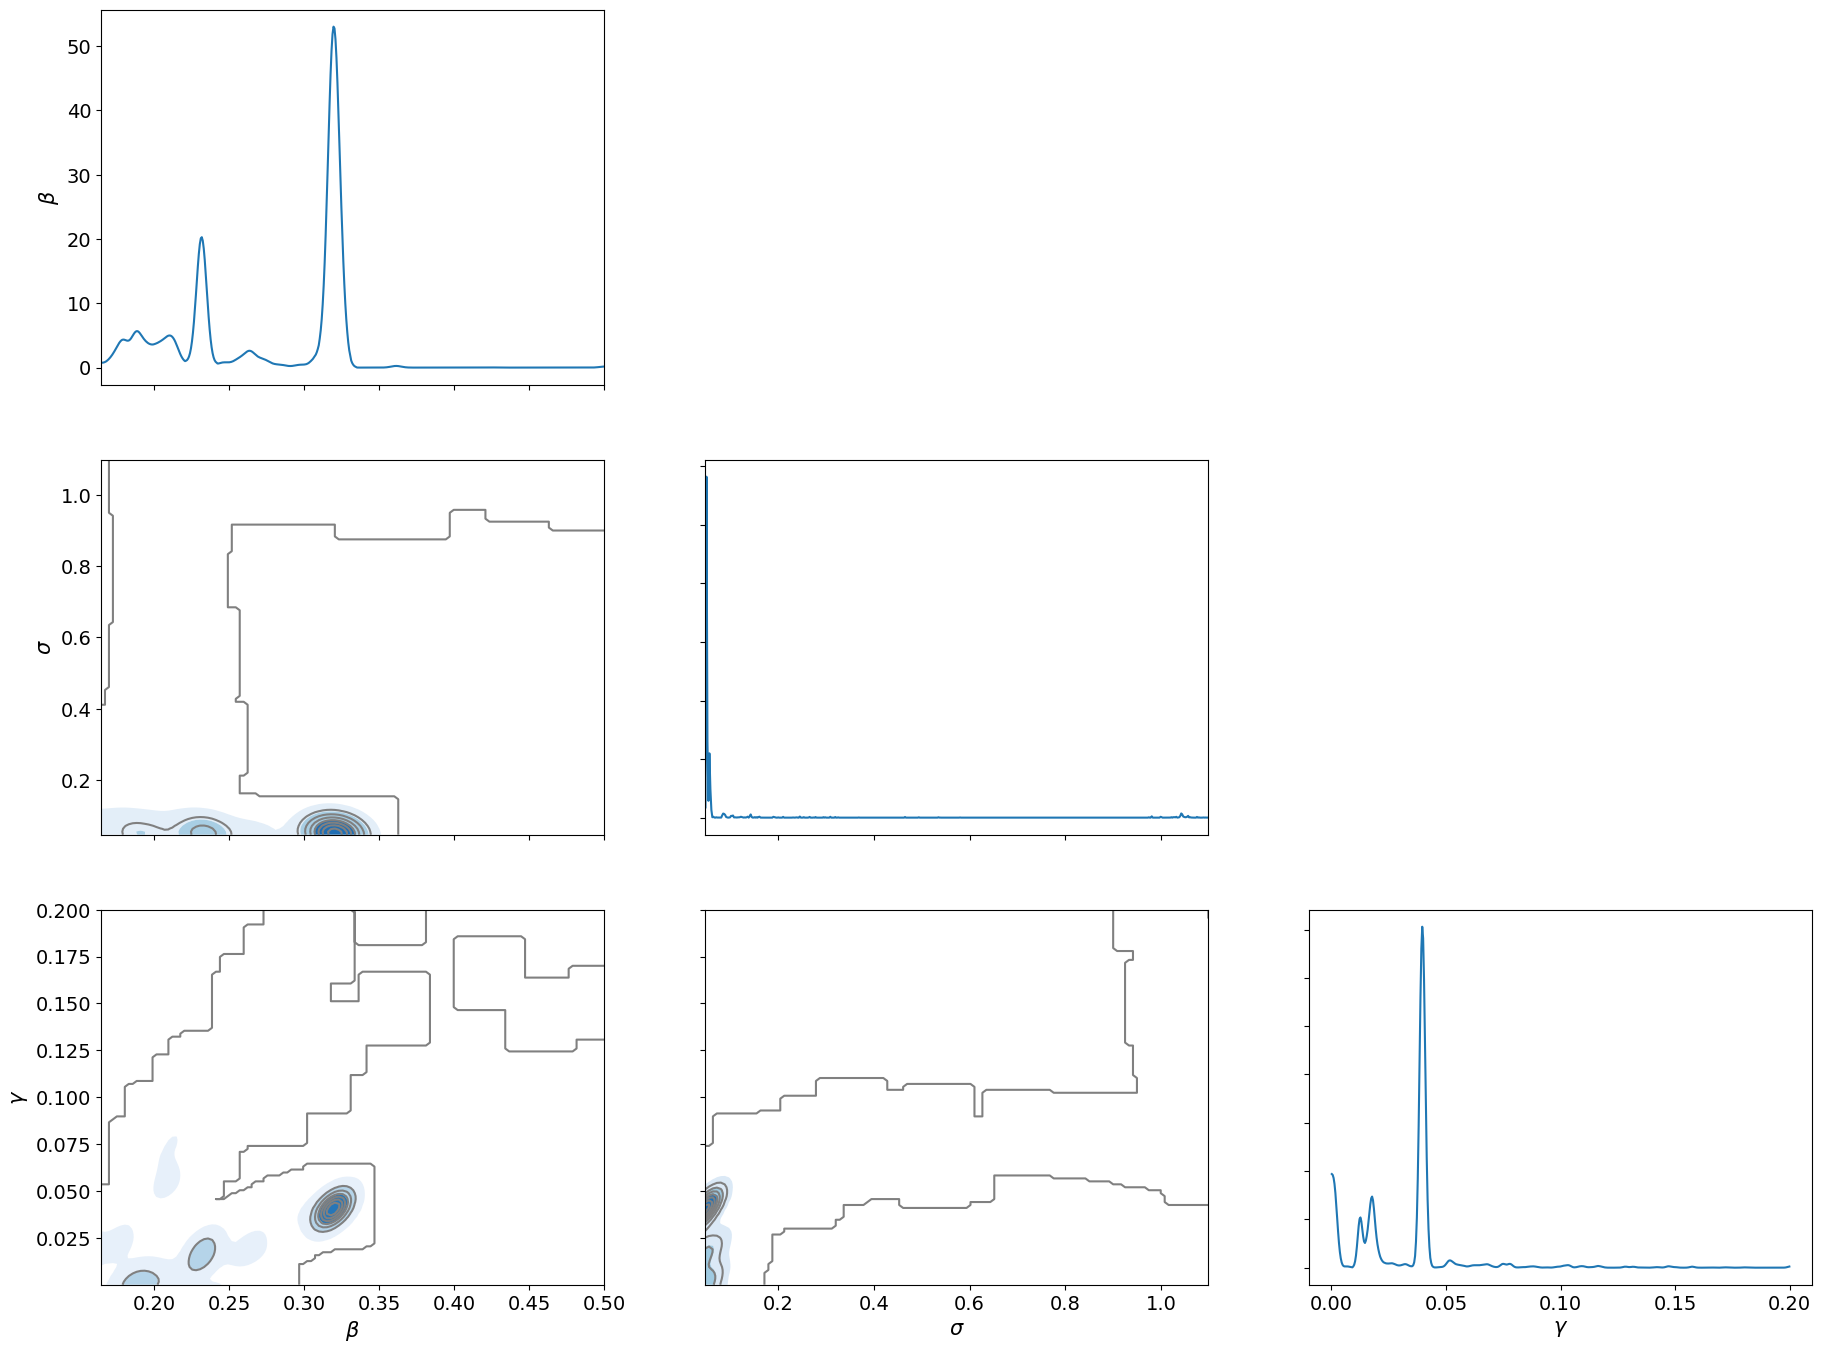

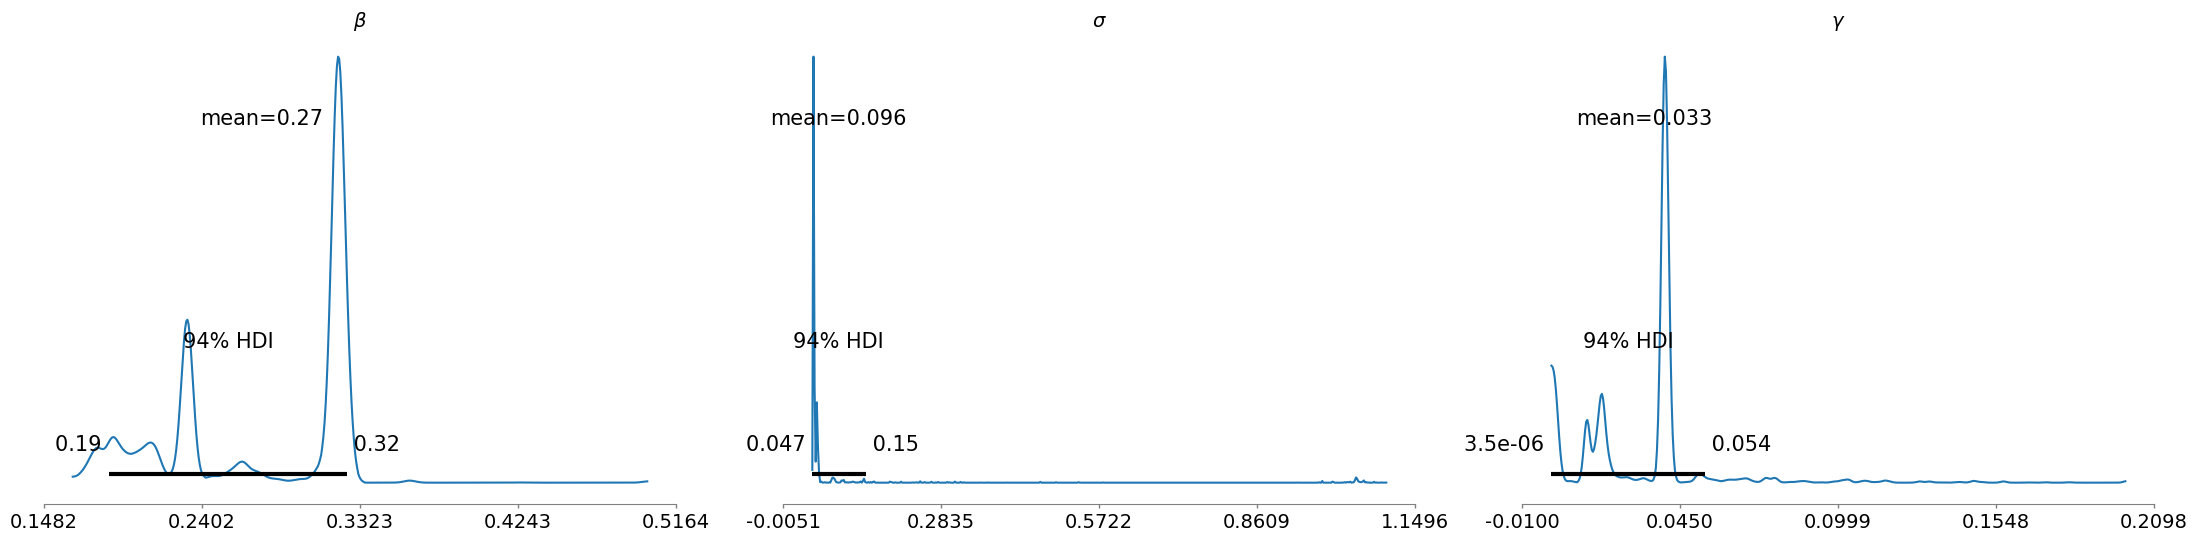

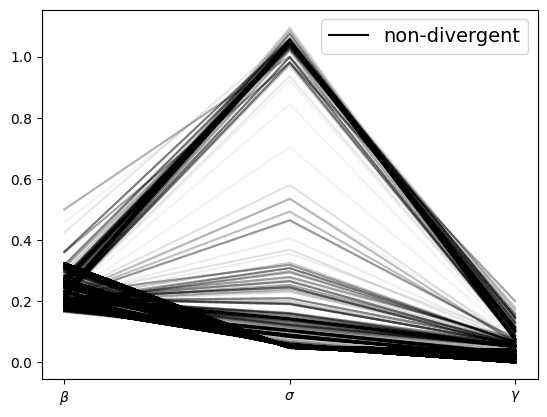

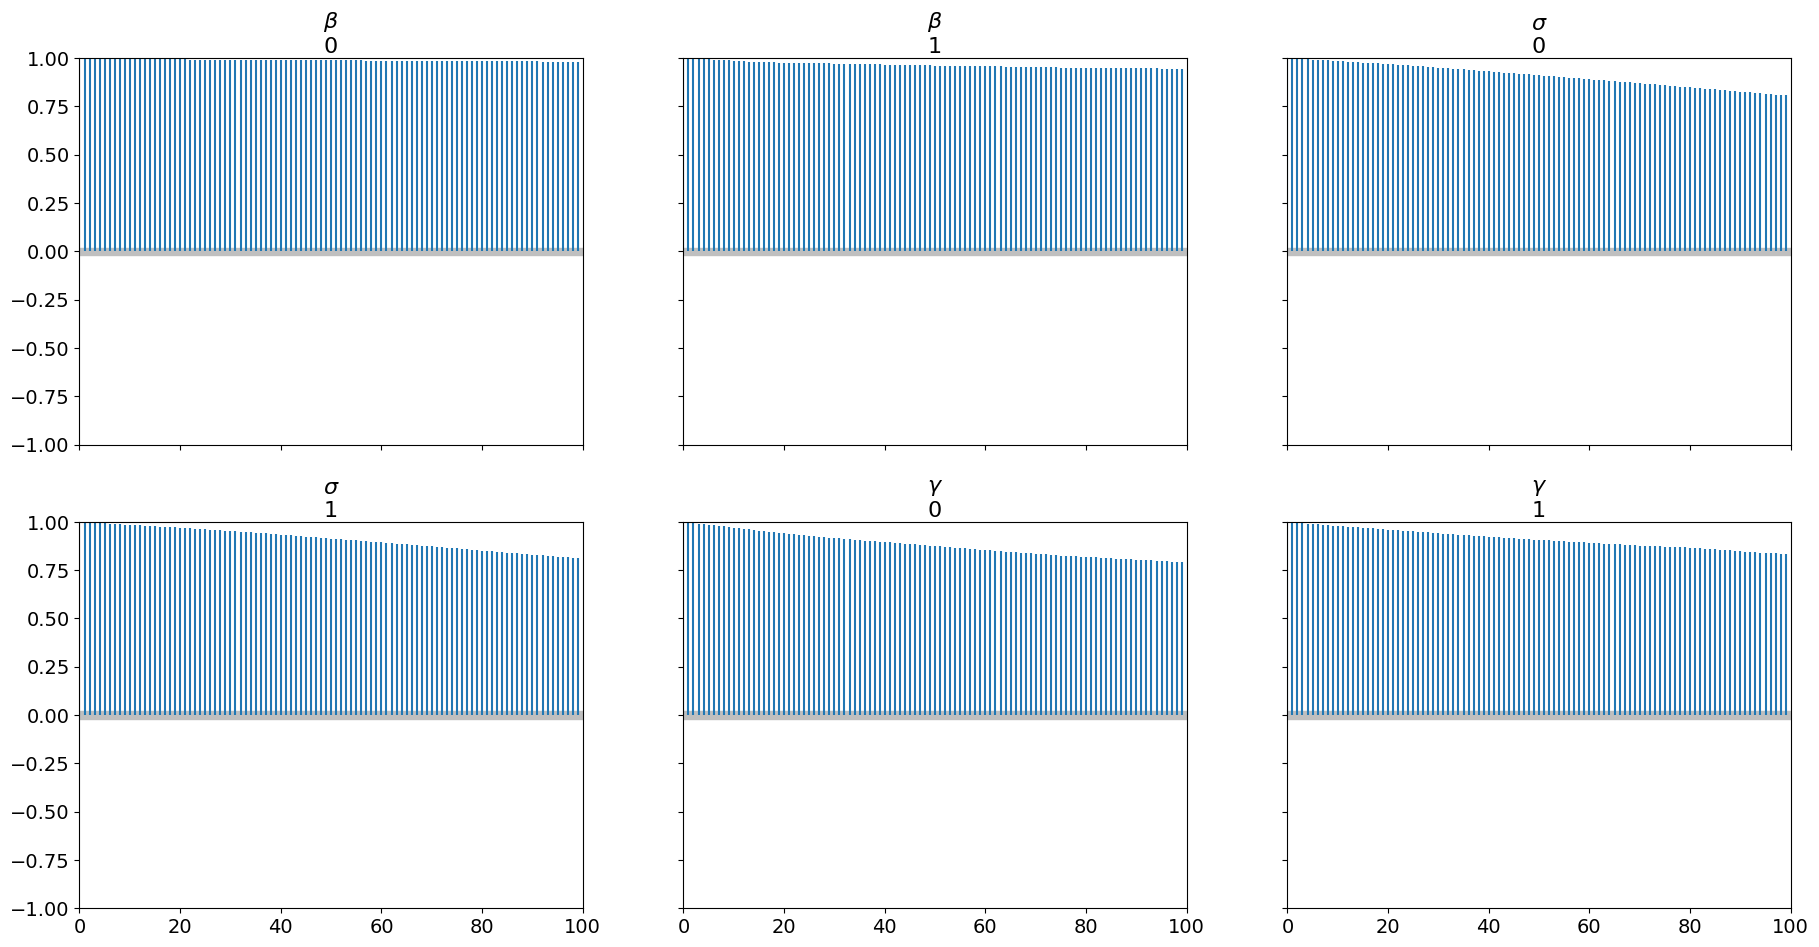

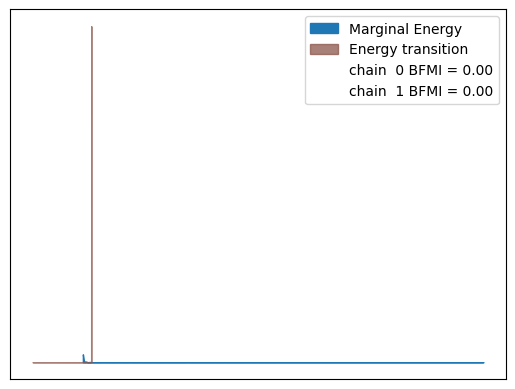

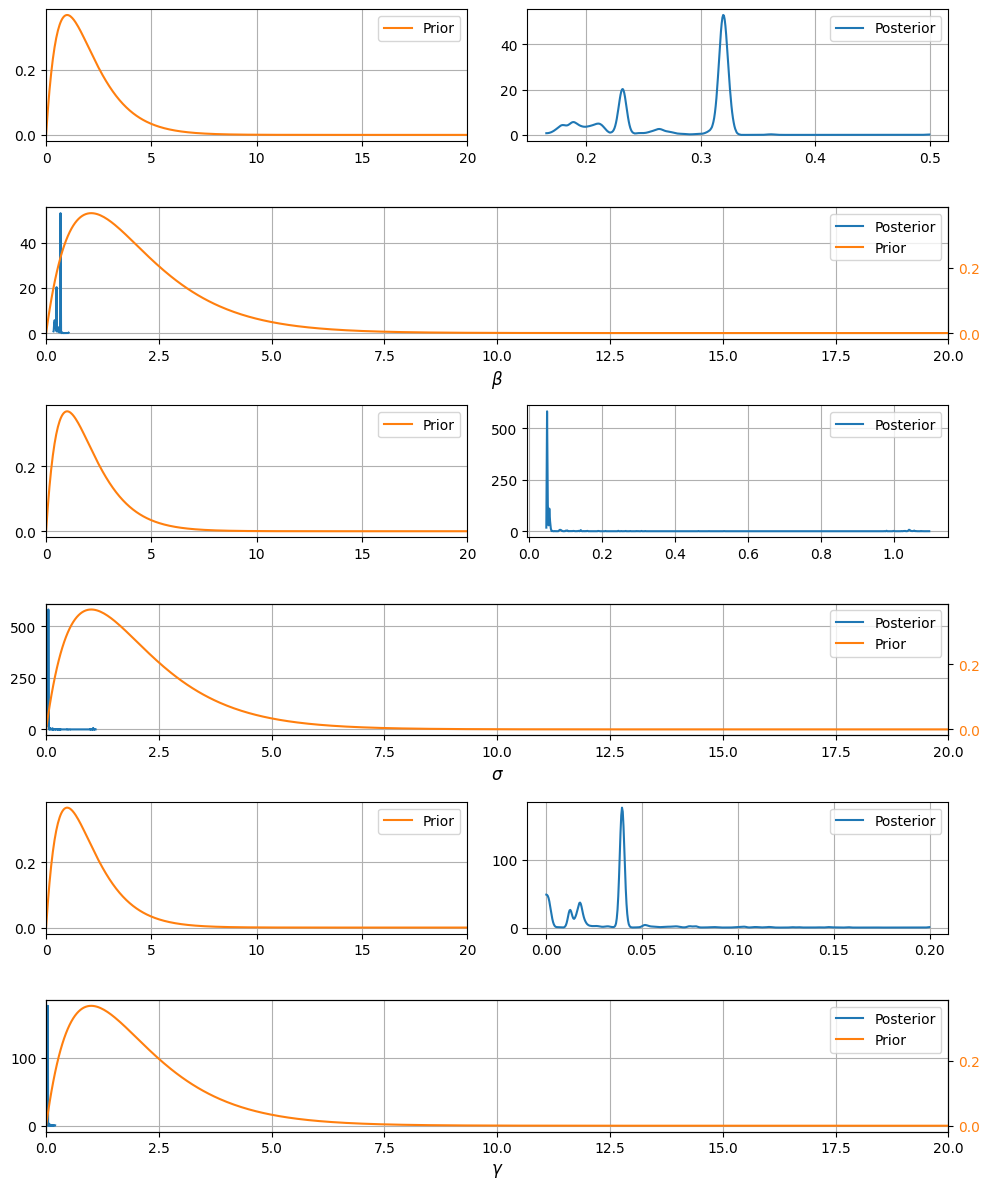

In [11]:
seir_twalk.create_dictionary()
seir_twalk.backend = 'matplotlib'
seir_twalk.report_results()

        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
beta   0.281  0.051   0.188    0.324      0.028    0.008       4.0      29.0   
sigma  0.052  0.005   0.050    0.060      0.002    0.001       5.0      25.0   
gamma  0.029  0.015   0.001    0.041      0.008    0.002       7.0      83.0   

       r_hat  
beta    1.48  
sigma   2.02  
gamma   1.76  


<Figure size 640x480 with 0 Axes>

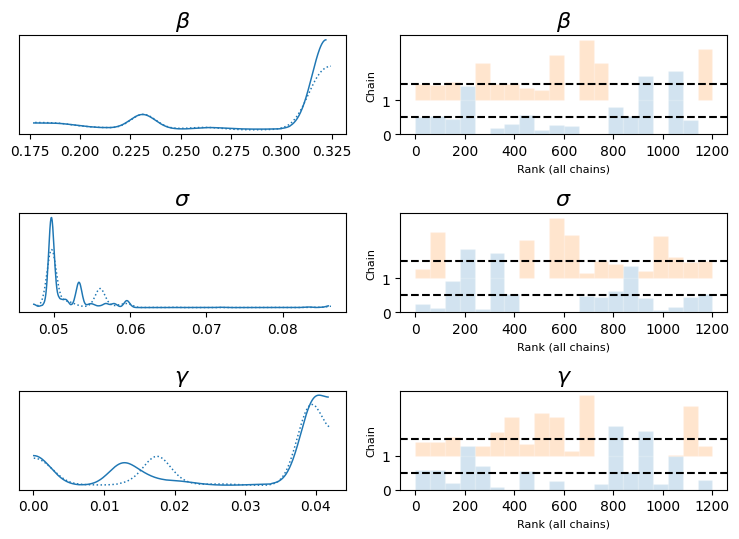

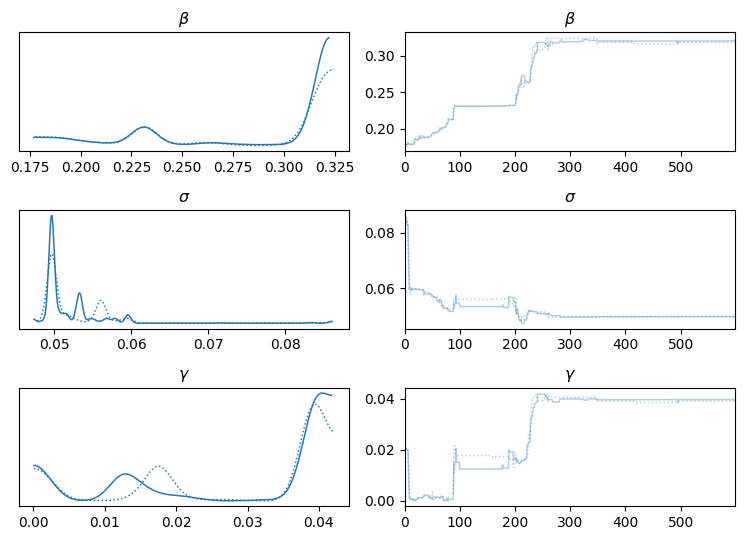

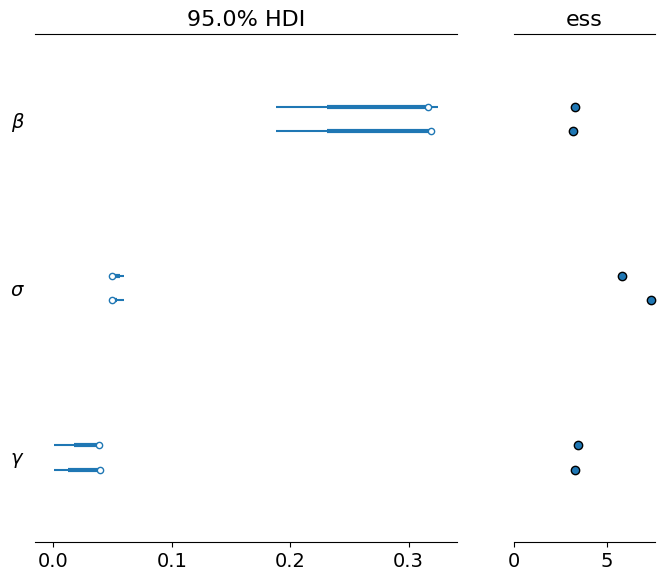

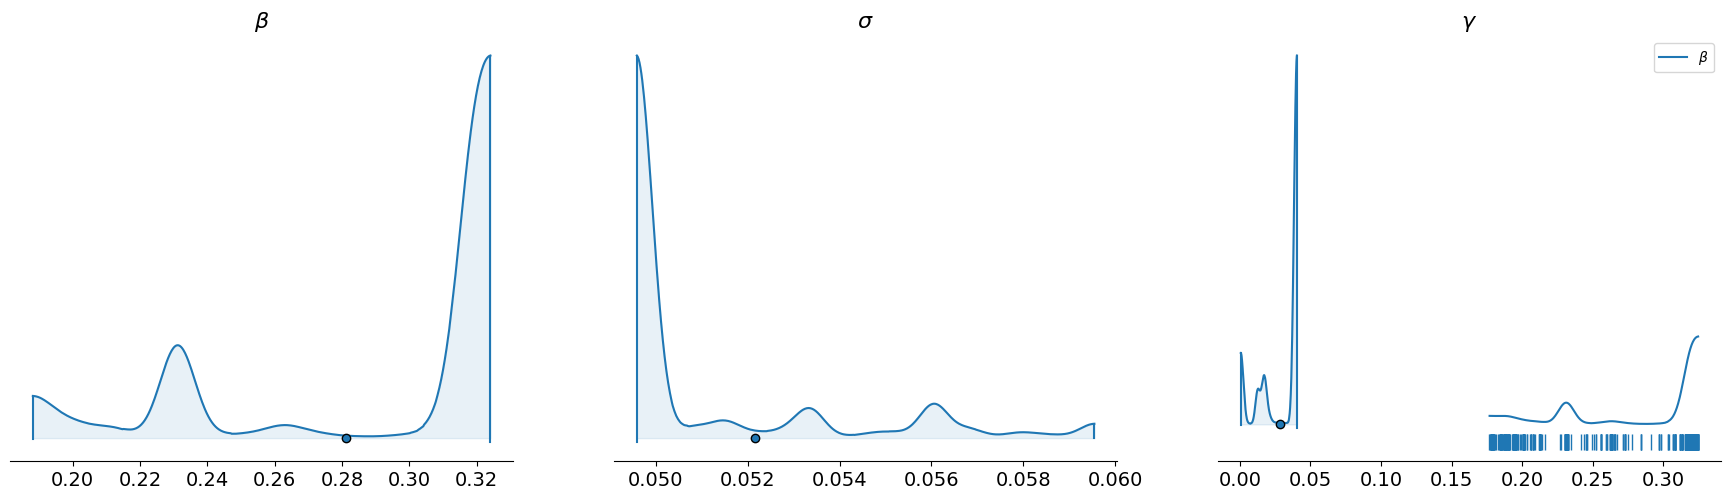

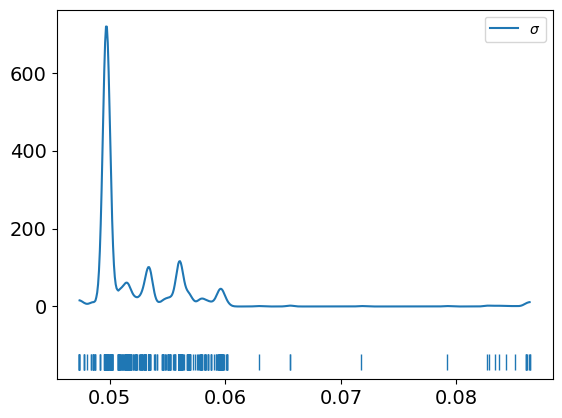

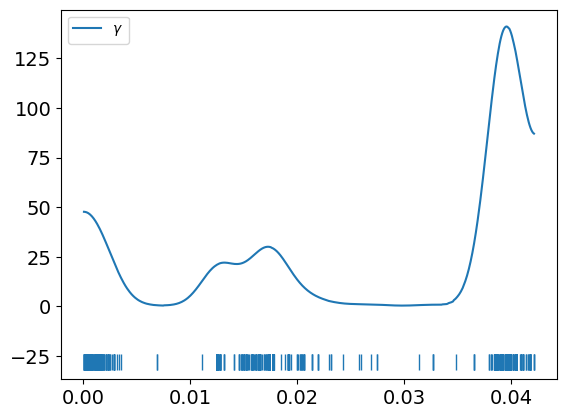

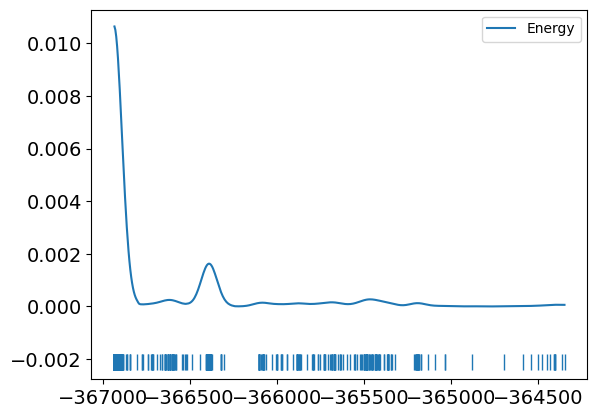

Generating 10 prior samples. Prior model: Gamma
Generating prior curves. Prior model: Gamma


/home/abel/seir_uq_methods/utils/AnalysisTools.py:295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:295: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_yticklabels(ax[i,j].get_yticklabels(), fontsize=10)
/home/abel/seir_uq_methods/utils/AnalysisTools.py:296: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i,j].set_xticklabels(ax[i,j].get_xticklabels(), fontsize=10)
/hom

Using 300 samples


100%|██████████| 600/600 [00:09<00:00, 60.93it/s]


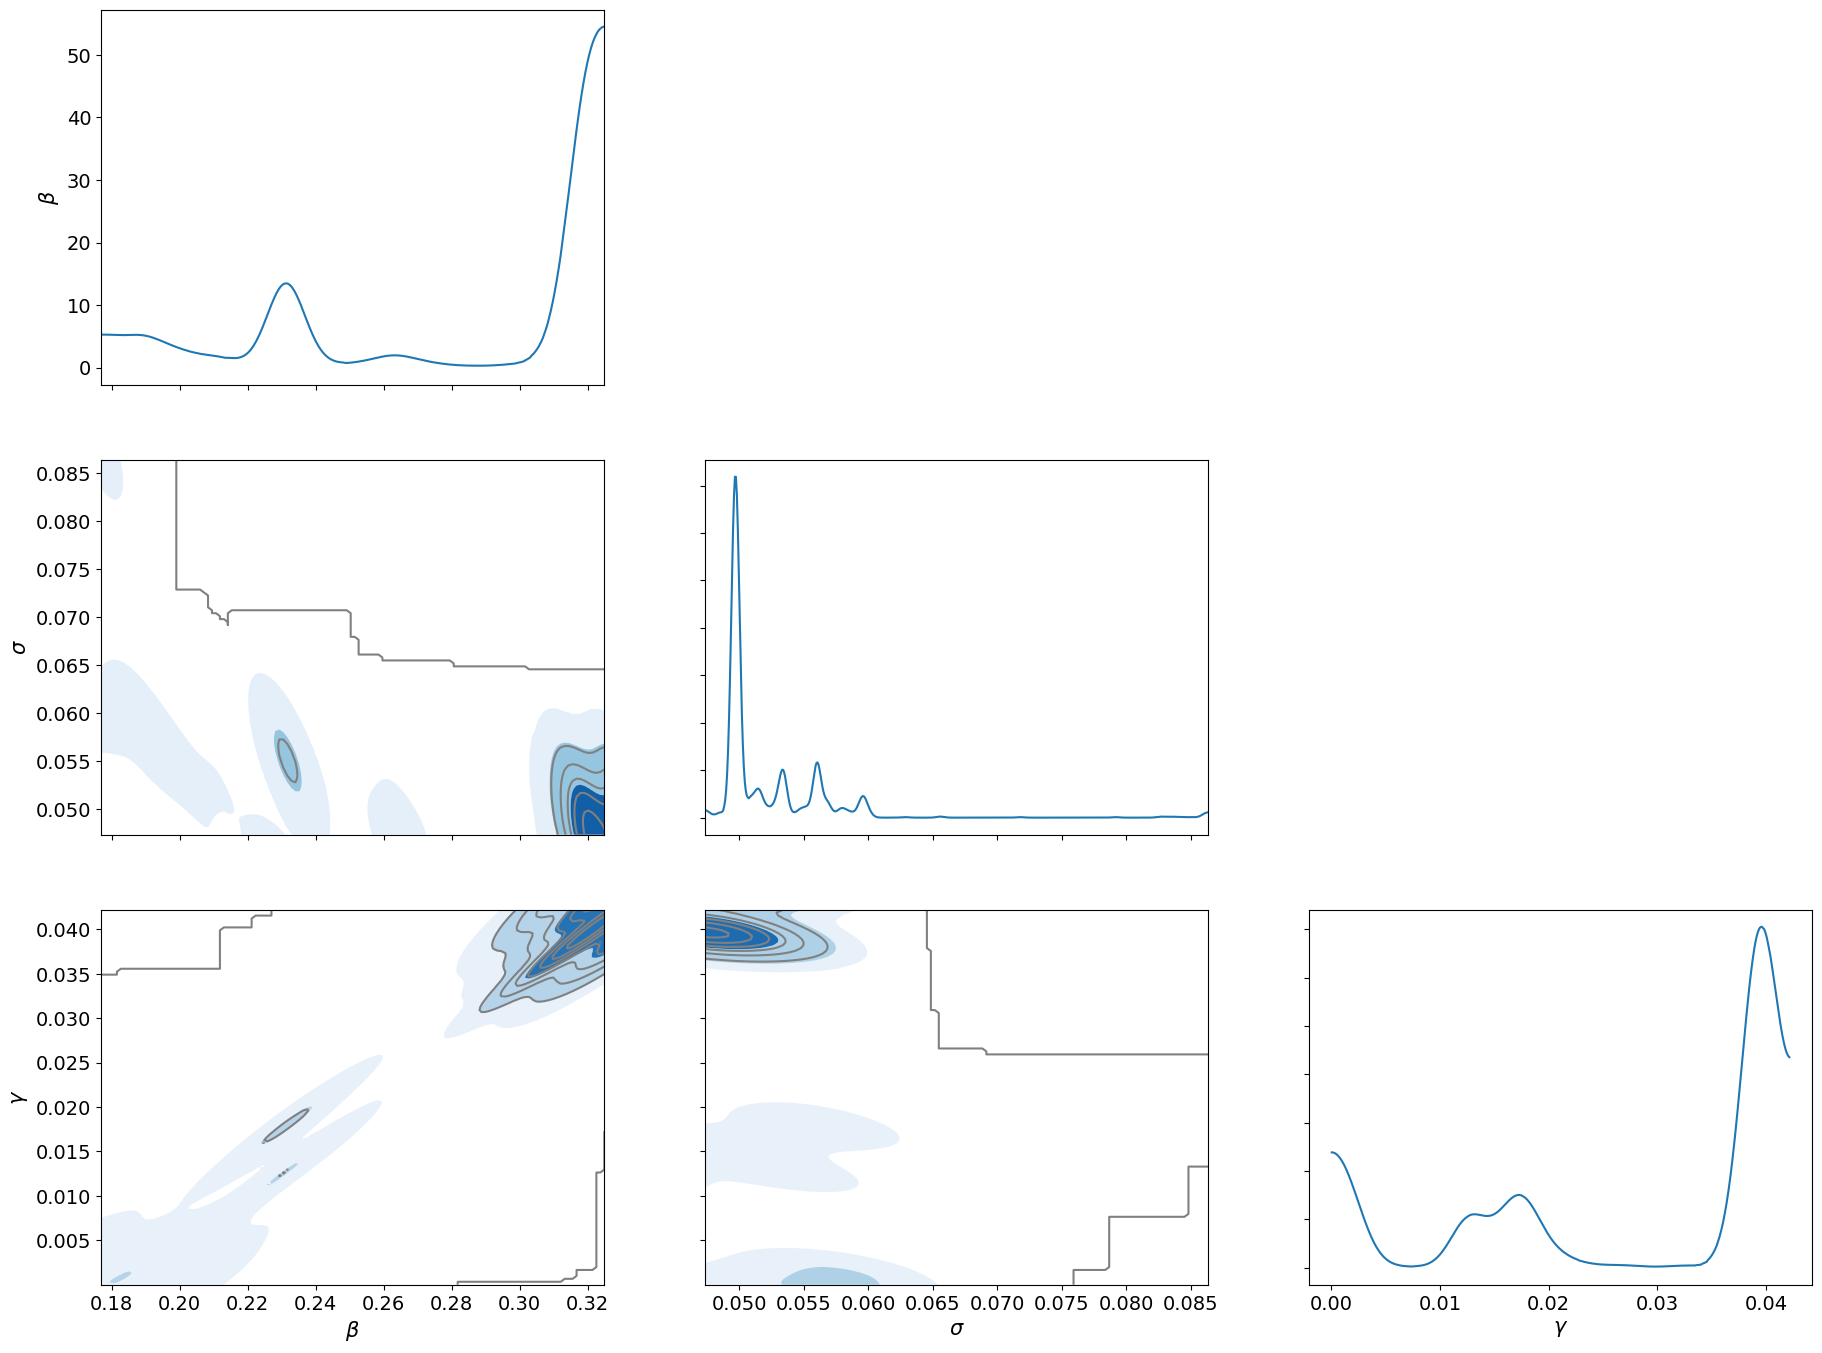

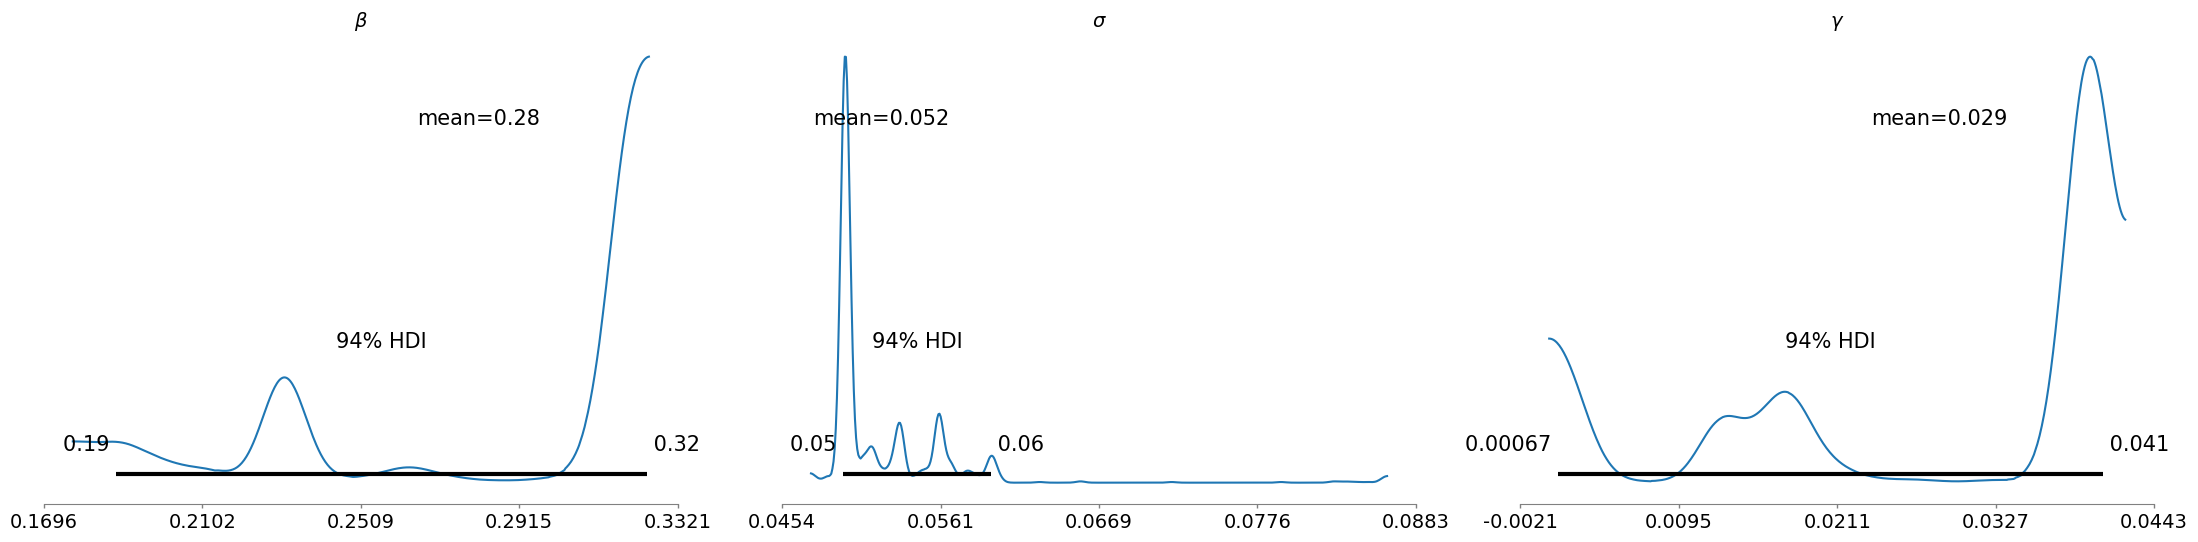

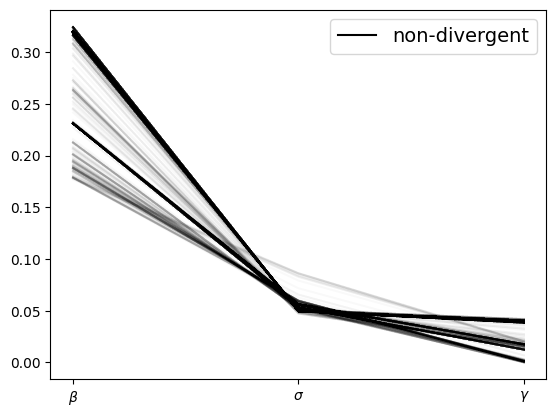

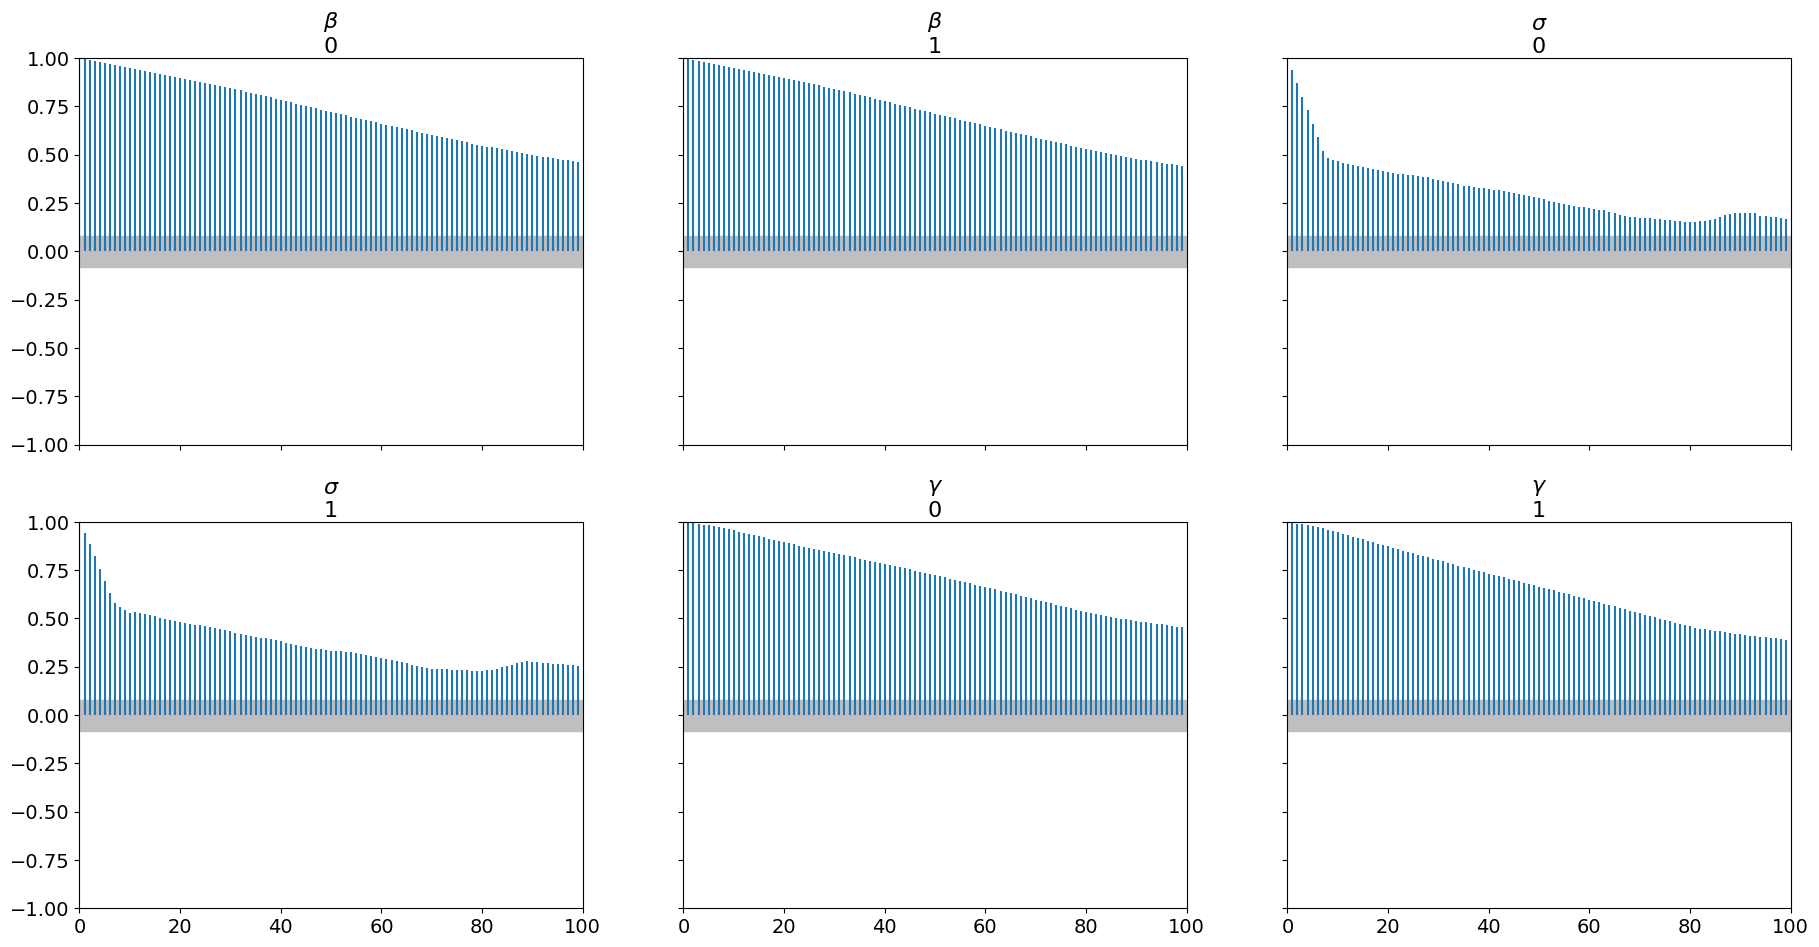

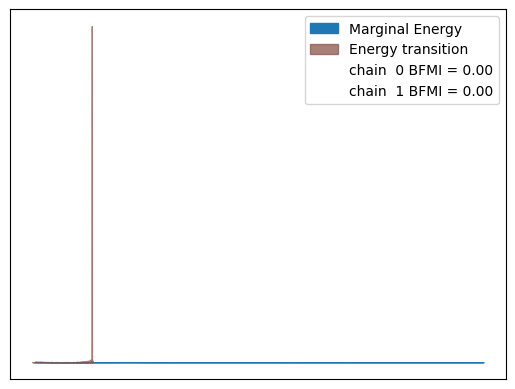

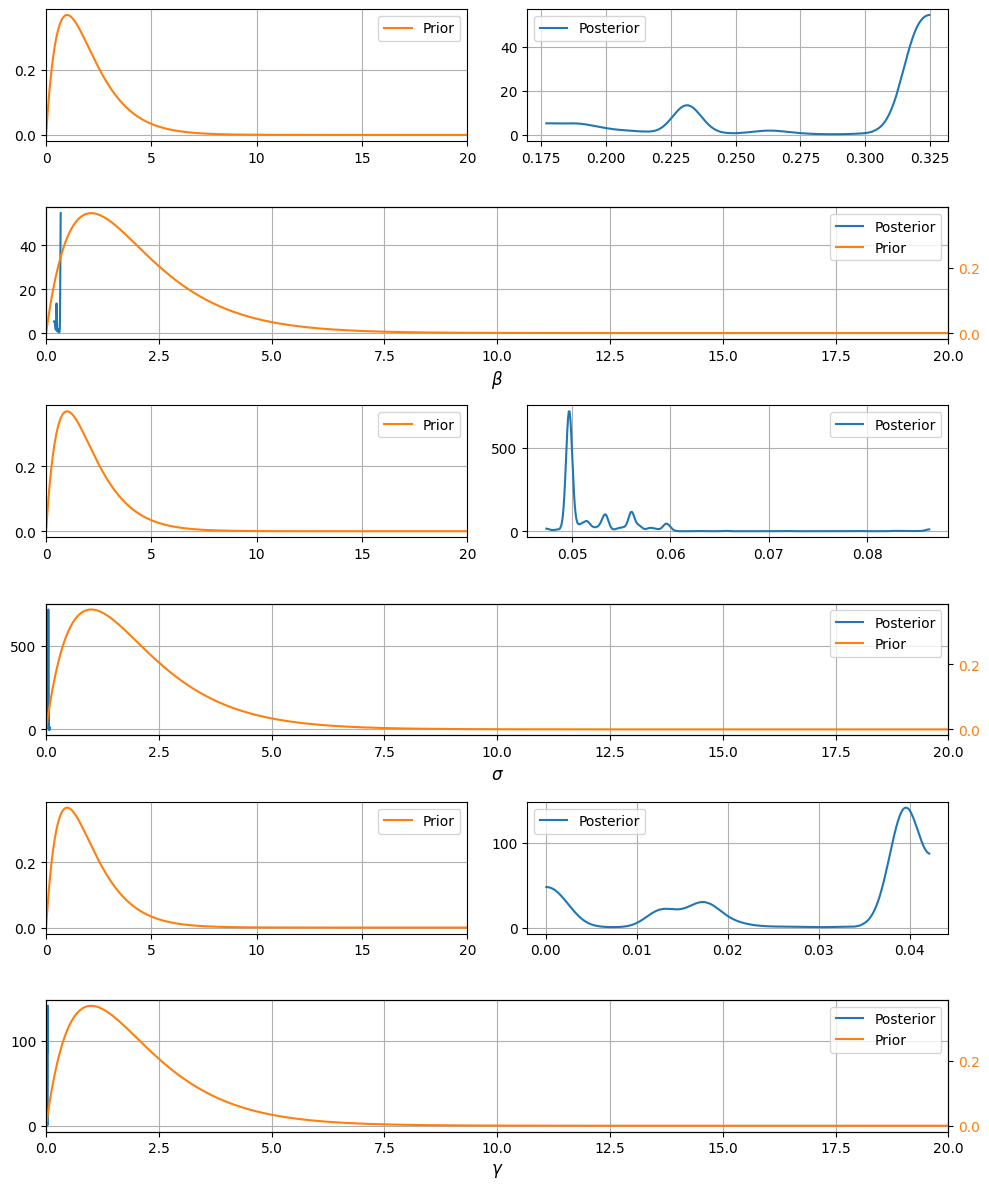

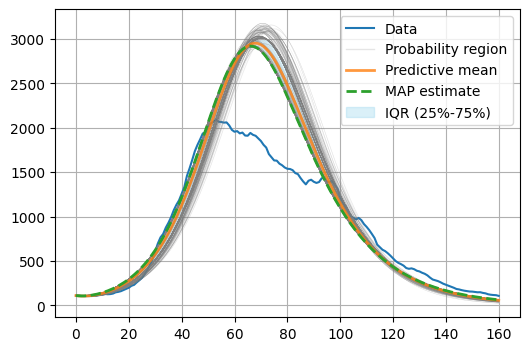

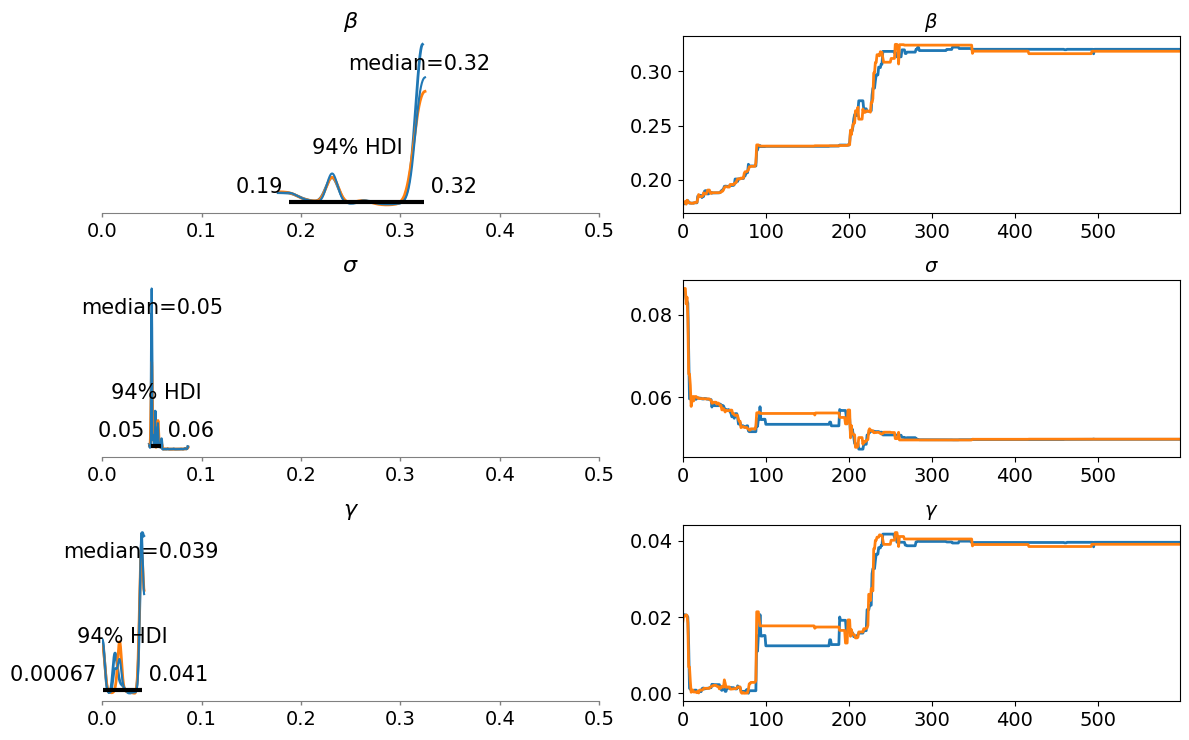

In [12]:
seir_twalk.create_dictionary(burnin=1000, subsample=15)

seir_twalk.report_results()

Using 300 samples


100%|██████████| 600/600 [00:09<00:00, 60.78it/s]


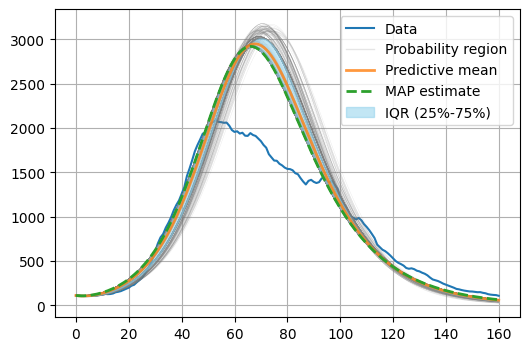

In [28]:
seir_twalk.plot_ppc()

In [ ]:
plt.plot(seir_twalk.idata.sample_stats.energy.values[:100].T)

In [ ]:
seir_twalk.plot_trace()

In [ ]:
seir_twalk.plot_dist_comparison()

In [ ]:
seir_twalk.plot_posterior_and_traces()

In [ ]:
seir_twalk.IAT()
